# **📈 Linear Regression Notes and Example**

A linear regression model is a foundational statistical and machine learning technique used to predict a continuous outcome (dependent variable) based on one or more predictor inputs (independent variables) by fitting a straight line to the data. The goal is to discover the best-fit line (or hyperplane) that minimizes the gap between the actual data points and the predicted values.

#### Simple Linear Regression
$y = \beta_0 + \beta_1 x$
where :
- y : the dependent variable (predicted outcome)
- x : the independent variable (predictor variable)
- $\beta_0$ : the y-intercept of the line
- $\beta_1$ : the slope (gradient)

#### Multiple Linear Regression
$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n$
where it uses multiple independent variables ($x_1$, $x_2$, ..., $x_n$)

#### How the model learns
The model figures out the best values for your coefficients ($\beta_0$, $\beta_1$) via Ordinary Least Squares (OLS). It works by calculating the vertical distance between the actual data points and the regression line (these distances are called residuals).

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
from matplotlib import pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/camnugent/california-housing-prices/housing.csv


# **Linear Regression**

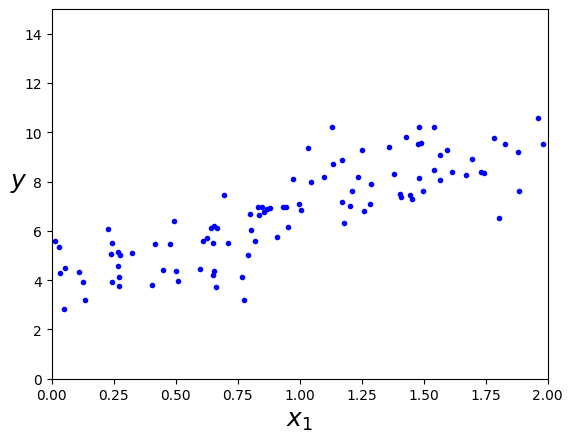

In [2]:
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 2, 0, 15])
plt.show()

In [3]:
X_b = np.c_[np.ones((100, 1)), X]  # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
theta_best

array([[3.8488237 ],
       [3.03593239]])

In [4]:
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]  # add x0 = 1 to each instance
y_predict = X_new_b.dot(theta_best)
y_predict

array([[3.8488237 ],
       [9.92068848]])

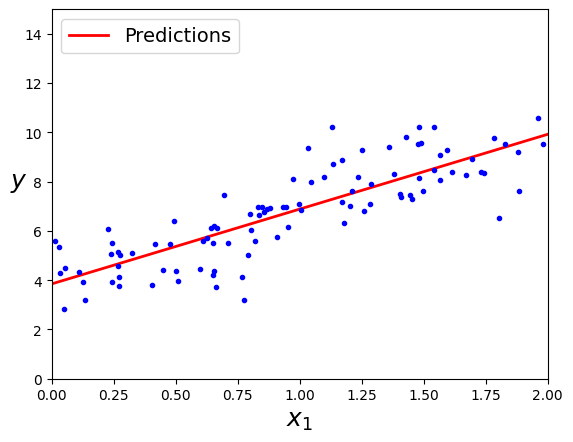

In [5]:
plt.plot(X_new, y_predict, "r-", linewidth=2, label="Predictions")
plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.axis([0, 2, 0, 15])
plt.show()

In [6]:
# sci-kit learn linear regression model
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([3.8488237]), array([[3.03593239]]))

In [7]:
lin_reg.predict(X_new)

array([[3.8488237 ],
       [9.92068848]])

# **🏡 California Housing Prices - Regression Model**
The data contains information from the 1990 California census. So although it may not help you with predicting current housing prices like the Zillow Zestimate dataset, it does provide an accessible introductory dataset for teaching people about the basics of machine learning

The data pertains to the houses found in a given California district and some summary stats about them based on the 1990 census data. Be warned the data aren't cleaned so there are some preprocessing steps required.

In [8]:
data = pd.read_csv('/kaggle/input/datasets/camnugent/california-housing-prices/housing.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [9]:
data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [14]:
data.dropna(subset=['total_bedrooms'], inplace=True)

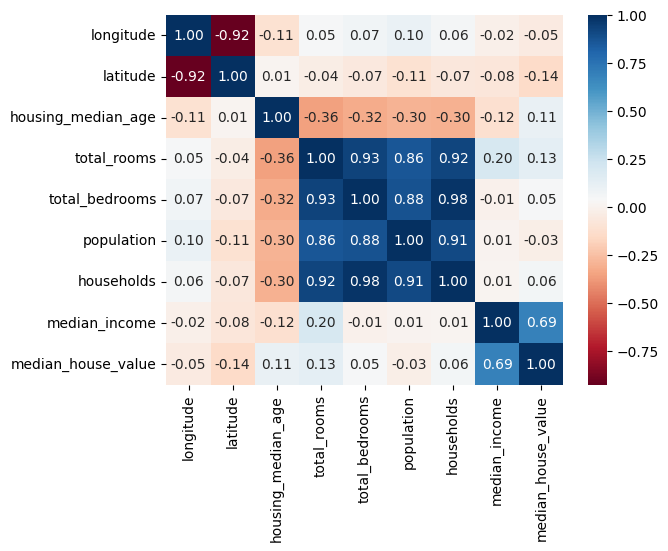

<Figure size 1600x3500 with 0 Axes>

In [27]:
columns_to_exclude = ['rooms_per_household', 'bedrooms_per_rooms', 'population_per_household']
corr_matrix = data.drop(columns=columns_to_exclude).corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu")

plt.figure(figsize=(16, 35))
plt.show()

Download successful!


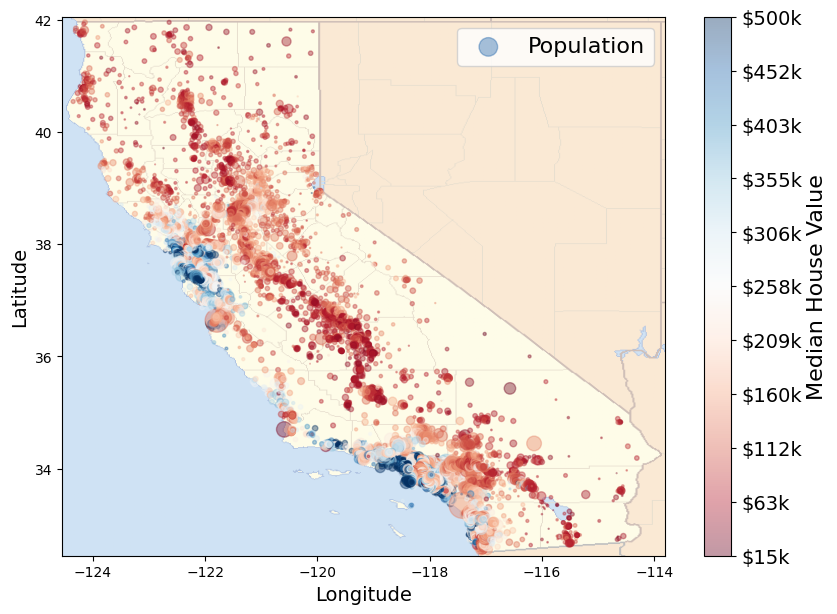

In [12]:
import matplotlib.image as mpimg
import urllib.request

# The correct domain for raw assets on GitHub
img_url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/images/end_to_end_project/california.png"
img_path = "california.png"

# Crucial: If a corrupted HTML file was already downloaded, delete it first
if os.path.exists(img_path):
    try:
        # Check if it's a fake PNG by looking at the first few characters
        with open(img_path, 'r', errors='ignore') as f:
            if "html" in f.read(100).lower():
                print("Removing corrupted/HTML placeholder file...")
                os.remove(img_path)
    except Exception:
        pass # If it's a binary file, it might throw a read error, which means it's likely a real image

# Now download the real asset safely
if not os.path.exists(img_path):
    print("Downloading California map image from raw source...")
    urllib.request.urlretrieve(img_url, img_path)
    print("Download successful!")

california_img = mpimg.imread(img_path)

scatter = data.plot(
    kind="scatter", x="longitude", y="latitude", figsize=(10, 7),
    s=data['population'] / 100, label="Population",
    c="median_house_value", cmap="RdBu", colorbar=False, alpha=0.4
)

# 3. Overlay the California map image
plt.imshow(california_img, extent=[-124.55, -113.80, 32.45, 42.05], alpha=0.5, cmap="jet")
plt.xlabel("Longitude", fontsize=14)
plt.ylabel("Latitude", fontsize=14)

# 4. Colorbar generation (Fix: Pass the scatter object explicitly)
prices = data["median_house_value"]
tick_values = np.linspace(prices.min(), prices.max(), 11)

# Grab the actual underlying PathCollection from the pandas plot axis object
sc = scatter.get_children()[0] 

cbar = plt.colorbar(sc)
cbar.set_ticks(tick_values)
cbar.set_ticklabels([f"${round(v/1000)}k" for v in tick_values], fontsize=14)
cbar.set_label('Median House Value', fontsize=16)

plt.legend(fontsize=16)
plt.show()

* greater high correlations are found in the house features set and population variables
* a larger median income correlates with higher house value
* houses near the beaches and in better neighbourhoods have higher median house value
* most low value houses are on the middle stretch of california with greater population density

In [22]:
data['rooms_per_household'] = data['total_rooms'] / data['households']
data['bedrooms_per_rooms'] = data['total_bedrooms'] / data['total_rooms']
data['population_per_household'] = data['population'] / data['households']

data[['rooms_per_household', 'bedrooms_per_rooms', 'population_per_household']].isna().sum()

rooms_per_household         0
bedrooms_per_rooms          0
population_per_household    0
dtype: int64

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 20433 non-null  float64
 1   latitude                  20433 non-null  float64
 2   housing_median_age        20433 non-null  float64
 3   total_rooms               20433 non-null  float64
 4   total_bedrooms            20433 non-null  float64
 5   population                20433 non-null  float64
 6   households                20433 non-null  float64
 7   median_income             20433 non-null  float64
 8   median_house_value        20433 non-null  float64
 9   ocean_proximity           20433 non-null  object 
 10  rooms_per_household       20433 non-null  float64
 11  bedrooms_per_rooms        20433 non-null  float64
 12  population_per_household  20433 non-null  float64
dtypes: float64(12), object(1)
memory usage: 2.2+ MB


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define the important features (X) and target variable (y)
# We include the engineered features and the independent strong predictors
features = [
    'median_income', 
    'housing_median_age', 
    'rooms_per_household', 
    'bedrooms_per_rooms', 
    'population_per_household'
]

X = data[features]
y = data['median_house_value']

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("======= MODEL METRICS =======")
print(f"R² Score (Accuracy/Variance Explained): {r2:.4f}")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

======= MODEL METRICS =======
R² Score (Accuracy/Variance Explained): 0.5446
Mean Absolute Error (MAE): $57,692.16
Root Mean Squared Error (RMSE): $78,914.89
